In [1]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import re

In [2]:
names = []
prices = []
ratings = []
discounts = []
old_prices = []
links = []
images = []
reviews = []
quantity = []
quantity_sold = []

In [3]:
base_url = "https://www.jumia.com.ng"

In [4]:
for page in range(1, 51):
    url = f"https://www.jumia.com.ng/smartphones//?page={page}"
    print(f"Scraping page {page}...")

    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    products = soup.select("article.prd")

    for item in products:
        # Product name
        name_tag = item.select_one("h3.name")
        names.append(name_tag.get_text(strip=True) if name_tag else None)

        # Price
        price_tag = item.select_one("div.prc")
        prices.append(price_tag.get_text(strip=True) if price_tag else None)

        # Old price
        old_price_tag = item.select_one("div.old")
        old_prices.append(old_price_tag.get_text(strip=True) if old_price_tag else None)

        # Image
        img_tag = item.select_one("img.img")
        images.append(img_tag.get("data-src") if img_tag else None)

        # Product link
        link_tag = item.select_one("a.core")
        links.append(base_url + link_tag.get("href") if link_tag else None)

        # Discount
        discount_tag = item.select_one("div.bdg._dsct._sm")
        discounts.append(discount_tag.get_text(strip=True) if discount_tag else None)

        # Rating
        rating_tag = item.select_one("div.stars._s")
        if rating_tag:
            rating_text = rating_tag.get_text(strip=True).split(" ")[0]
            ratings.append(rating_text)
        else:
            ratings.append(None)

        # Review count
        review_tag = item.select_one("div.rev")
        if review_tag:
            review_text = review_tag.get_text(strip=True)
            review_number = review_text.split("(")[-1].replace(")", "")
            reviews.append(review_number)
        else:
            reviews.append(None)

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Scraping page 36...
Scraping page 37...
Scraping page 38...
Scraping page 39...
Scraping page 40...
Scraping page 41...
Scraping page 42...
Scraping page 43...
Scraping page 44...
Scraping page 45...
Scraping page 46...
Scraping page 47...
Scraping page 48...
Scraping page 49...
Scraping page 50...


In [6]:
product_info = pd.DataFrame({
    "name": names,
    "price": prices,
    "image": images,
    "link": links,
    "discount": discounts,
    "rating": ratings,
    "reviews": reviews
})

In [7]:
product_info.to_csv('product_info.csv', index=False, header=True)

product_info

,name,price,image,link,discount,rating,reviews
0,NaN,"₦ 214,239",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-m7-6.9-6gb-ram-1...,NaN,NaN,NaN
1,NaN,"₦ 181,426",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/blackview-fort-1-rugg...,NaN,NaN,NaN
2,NaN,"₦ 303,906",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a17-6....,NaN,NaN,NaN
3,NaN,"₦ 107,690",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/oale-17-pro-max-andro...,NaN,NaN,NaN
4,NaN,"₦ 349,800",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/vivo-y31d-6.74-120hz-...,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2033,Huawei Mate X7 8.0'' Foldable 16GB RAM 512GB R...,"₦ 2,100,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/huawei-mate-x7-8.0-fo...,NaN,NaN,NaN
2034,"Realme Note 50 - 6.74"" (4GB RAM, 128GB ROM) An...","₦ 175,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/realme-note-50-6.74-4...,13%,NaN,NaN
2035,itel A200+ 3gb (Expandable to 8gb Ram) 64gb Ro...,"₦ 145,500",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/itel-a200-3gb-expanda...,8%,4,1
2036,Hmd LUMA 8GB RAM+128GB ROM 50MP Camera DUAL SI...,"₦ 199,999",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/hmd-luma-8gb-ram128gb...,9%,NaN,NaN


In [8]:
product_info.to_excel("jumia.xlsx", index=False)
product_info

,name,price,image,link,discount,rating,reviews
0,NaN,"₦ 214,239",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-m7-6.9-6gb-ram-1...,NaN,NaN,NaN
1,NaN,"₦ 181,426",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/blackview-fort-1-rugg...,NaN,NaN,NaN
2,NaN,"₦ 303,906",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a17-6....,NaN,NaN,NaN
3,NaN,"₦ 107,690",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/oale-17-pro-max-andro...,NaN,NaN,NaN
4,NaN,"₦ 349,800",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/vivo-y31d-6.74-120hz-...,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2033,Huawei Mate X7 8.0'' Foldable 16GB RAM 512GB R...,"₦ 2,100,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/huawei-mate-x7-8.0-fo...,NaN,NaN,NaN
2034,"Realme Note 50 - 6.74"" (4GB RAM, 128GB ROM) An...","₦ 175,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/realme-note-50-6.74-4...,13%,NaN,NaN
2035,itel A200+ 3gb (Expandable to 8gb Ram) 64gb Ro...,"₦ 145,500",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/itel-a200-3gb-expanda...,8%,4,1
2036,Hmd LUMA 8GB RAM+128GB ROM 50MP Camera DUAL SI...,"₦ 199,999",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/hmd-luma-8gb-ram128gb...,9%,NaN,NaN


In [9]:
product_info.isna().sum()

name          38
price          0
image          0
link           0
discount     753
rating      1225
reviews     1225
dtype: int64

In [10]:
product_info = product_info.dropna(subset = ['name'])

In [11]:
product_info = product_info.dropna(subset=["link"])

In [12]:
product_info["discount"] = product_info["discount"].fillna(0)

In [13]:
product_info["rating"] = product_info["rating"].fillna(0)

In [14]:
product_info["reviews"] = product_info["reviews"].fillna(0)

In [15]:
product_info.isna().sum()

name        0
price       0
image       0
link        0
discount    0
rating      0
reviews     0
dtype: int64

In [16]:
product_info.duplicated('name').sum()

np.int64(159)

In [17]:
duplicates = product_info[product_info.duplicated(keep=False)]
duplicates.sort_values("name").head(20)

,name,price,image,link,discount,rating,reviews
1717,Motorola Edge 70 5G 6.7'' 12GB RAM 512GB ROM A...,"₦ 780,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/motorola-edge-70-5g-6...,3%,0,0
1718,Motorola Edge 70 5G 6.7'' 12GB RAM 512GB ROM A...,"₦ 780,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/motorola-edge-70-5g-6...,3%,0,0
1877,Samsung Galaxy A57 5G - Dual SIM - 8GB RAM - 2...,"₦ 600,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a57-5g...,14%,0,0
1878,Samsung Galaxy A57 5G - Dual SIM - 8GB RAM - 2...,"₦ 600,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a57-5g...,14%,0,0
197,Samsung Galaxy S22 Plus 5G - 6.6'' (256GB/8GB)...,"₦ 400,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/galaxy-s22-plus-5g-6....,9%,4.7,3
198,Samsung Galaxy S22 Plus 5G - 6.6'' (256GB/8GB)...,"₦ 400,000",https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/galaxy-s22-plus-5g-6....,9%,4.7,3


In [18]:
product_info = product_info.drop_duplicates(subset="link", keep="first")

In [19]:
product_info = product_info.drop_duplicates(subset="link", keep="first")

print(product_info.shape)

(1997, 7)


In [20]:
product_info["name"] = (
    product_info["name"]
    .str.replace("GBGB", "GB", regex=False)
)

In [21]:
product_info["link"].value_counts().head(10)

link
https://www.jumia.com.ng/samsung-galaxy-a07-6.7-4gb-ram128gbgb-rom-black-418619812.html                                                                                                   1
https://www.jumia.com.ng/xiaomi-redmi-a7-pro-6.9-4gb-ram128gb-rom-black-419511167.html                                                                                                    1
https://www.jumia.com.ng/samsung-galaxy-a17-6.7-hd-6gb-ram128gb-rom-android-14-black-418894272.html                                                                                       1
https://www.jumia.com.ng/poco-c81-pro-6.9-4gb-ram-128gb-rom-android-15-black-419852123.html                                                                                               1
https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-4gbram128gb-rom-android-15-midnight-black-418597148.html                                                                                    1
https://www.jumia.com.ng/poco-c85-6.9-6gb-ram-128gb-rom

In [22]:
print("Shape:", product_info.shape)

print("Duplicate rows:", product_info.duplicated().sum())

print("Duplicate links:", product_info["link"].duplicated().sum())

print("Unique links:", product_info["link"].nunique())

Shape: (1997, 7)
Duplicate rows: 0
Duplicate links: 0
Unique links: 1997


In [23]:
product_info[product_info["price"].str.contains("-", na=False)]["price"].head(20)

66          ₦ 114,079 - ₦ 123,998
152         ₦ 280,000 - ₦ 290,000
433         ₦ 340,000 - ₦ 350,000
761         ₦ 183,500 - ₦ 183,600
763     ₦ 1,898,000 - ₦ 1,998,000
970     ₦ 1,898,000 - ₦ 1,998,000
1305        ₦ 700,000 - ₦ 850,000
1421        ₦ 337,250 - ₦ 360,000
1580    ₦ 2,800,000 - ₦ 3,095,000
2004    ₦ 2,800,000 - ₦ 3,095,000
Name: price, dtype: str

In [24]:
def clean_price(price):
    if pd.isna(price):
        return np.nan

    # Convert to string
    price = str(price)

    # Remove the currency symbol and commas
    price = re.sub(r"[₦,]", "", price).strip()

    # Handle price ranges
    if "-" in price:
        low, high = [x.strip() for x in price.split("-")]
        return (float(low) + float(high)) / 2

    # Handle single prices
    return float(price)

product_info["price"] = product_info["price"].apply(clean_price)

In [25]:
print(product_info["price"].dtype)

product_info["price"].describe()

float64


count    1.997000e+03
mean     5.632335e+05
std      6.230395e+05
min      1.700000e+04
25%      1.999990e+05
50%      3.400000e+05
75%      6.500000e+05
max      7.777777e+06
Name: price, dtype: float64

In [26]:
product_info[product_info["price"] == product_info["price"].max()]

,name,price,image,link,discount,rating,reviews
983,"Samsung Galaxy Z Trifold - 10"" (16GB RAM, 512G...",7777777.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/galaxy-z-trifold-10-1...,22%,0,0


In [27]:
#product_info.drop(index=533, inplace=True)
#product_info.drop(index=2685, inplace=True)
#product_info.drop(index=2613, inplace=True)

In [28]:
import re

keywords = [
    "Headset",
    "Earbuds",
    "Earphone",
    "Bluetooth",
    "Watch",
    "Charger",
    "Power Bank",
    "Cable",
    "Speaker",
    "Projector"
]

pattern = r'\b(?:' + '|'.join(map(re.escape, keywords)) + r')\b'

mask = product_info["name"].str.contains(
    pattern,
    case=False,
    na=False,
    regex=True
)

product_info.loc[mask, "name"]

99      Renewed Huawei Y5P Black 5.45" 4+64G 8MP 3020m...
105     OPPO A31 Black 6.5" 6+128G 12MP+2MP+2MP 4230mA...
108     Samsung Galaxy A07 6.7" 4GB RAM/ 128GB ROM And...
121     Huawei Y9 2019 Black 6.5" 6+128G 16MP+2MP 4000...
133     Vivo Y93s Black 6.2" 6+128G 13MP+2MP 4030mAh W...
135     OPPO A3s Purple 6.2" 4+64G 13MP+2MP 3400mAh Wi...
136     OUKITEL WP55S Rugged 256GB Smartphone 6.6" FHD...
145     OUKITEL WP56 5G Rugged Smartphone 6.8''FHD+, 1...
150     OUKITEL WP55S Rugged Smartphones 256GB/8GB, 6....
162     OPPO A31 Green 6.5" 6+128G 12MP+2MP+2MP 4230mA...
166     OUKITEL C66 Android 16 Smartphones 6.73"HD, 64...
263     Samsung Galaxy A07 6.7" 4GB RAM/ 64GB ROM Andr...
716     itel City 200  7.45mm" 128/4+4gb Unibody Metal...
733     OUKITEL C66 Android 16 Smartphone 64MP AI Came...
768     OUKITEL WP53S Rugged Smartphone, 11000mAh Big ...
841     OPPO A31 Red  6GB 128GB  6.5” HD+ Large Displa...
847     Oppo Reno9 5G 12GB RAM, 256GB ROM, 120Hz 3D Cu...
851     Samsun

In [29]:
product_info[product_info["price"] == product_info["price"].min()]

,name,price,image,link,discount,rating,reviews
1705,itel It2160,17000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/it2160-itel-mpg119947...,0,0,0


In [30]:
product_info.loc[232]

name        FOSSiBOT S7-6.67",4/128GB,8MP,Android 14,5000m...
price                                                162599.0
image       https://ng.jumia.is/unsafe/fit-in/300x300/filt...
link        https://www.jumia.com.ng/fossibot-s7-6.674128g...
discount                                                   1%
rating                                                      4
reviews                                                     1
Name: 232, dtype: object

In [31]:
import pandas as pd
import numpy as np
import re

# -----------------------
# Brand (first word)
# -----------------------
product_info["brand"] = product_info["name"].str.extract(r"^(\S+)")

# -----------------------
# RAM
# Matches:
# 4GB RAM
# 6GB+128GB
# 256GB/8GB
# (8GB RAM, ...)
# -----------------------
product_info["ram"] = (
    product_info["name"]
    .str.extract(
        r'(\d+\+?\d*GB)\s*RAM|'
        r'(\d+GB)(?=\+)|'
        r'(?<=/)(\d+GB)(?=[,\s)]|$)',
        flags=re.IGNORECASE
    )
    .bfill(axis=1)
    .iloc[:,0]
)

# -----------------------
# Storage
# Matches:
# 128GB ROM
# 256GB
# 256/8GB
# RAM/64GB ROM
# -----------------------
product_info["storage"] = (
    product_info["name"]
    .str.extract(
        r'(\d+GB)\s*ROM|'
        r'(\d+GB)(?=\s*-\s)|'
        r'(\d+GB)(?=/\d+GB)|'
        r'(?<=\+)(\d+GB)',
        flags=re.IGNORECASE
    )
    .bfill(axis=1)
    .iloc[:,0]
)

# -----------------------
# Android / iOS
# -----------------------
product_info["os"] = (
    product_info["name"]
    .str.extract(r'(Android\s*\d+|iOS\s*\d+)', flags=re.IGNORECASE)
)

# -----------------------
# Color
# Usually after the last dash
# -----------------------
product_info["color"] = (
    product_info["name"]
    .str.extract(r'-\s*([A-Za-z ]+)$')
)

# -----------------------
# Model
# Remove extracted specs from the name
# -----------------------
product_info["model"] = (
    product_info["name"]
        .str.replace(r'^\S+\s+', '', regex=True)
        .str.replace(r'\d+\.\d+\s*(?:\"|\'\'|Inch|Inches|inch)', '', regex=True, flags=re.I)
        .str.replace(r'\d+\+?\d*GB\s*RAM', '', regex=True, flags=re.I)
        .str.replace(r'\d+GB\s*ROM', '', regex=True, flags=re.I)
        .str.replace(r'Android\s*\d+', '', regex=True, flags=re.I)
        .str.replace(r'iOS\s*\d+', '', regex=True, flags=re.I)
        .str.replace(r'-.*$', '', regex=True)
        .str.strip()
)

In [32]:
import pandas as pd
import numpy as np
import re

product_info["name"] = (
    product_info["name"]
    .str.replace("GBGB", "GB", regex=False)
    .str.replace("RAB", "RAM", regex=False)
    .str.replace("ROMROM", "ROM", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [33]:
brands = [
    "Samsung","Apple","iPhone","Xiaomi","Redmi","Poco",
    "Tecno","Infinix","Huawei","Google","Pixel",
    "Oppo","OPPO","Vivo","itel","OnePlus",
    "Honor","Doogee","OUKITEL","Blackview",
    "FreeYond","Ruioo","MKTEL","UMIDIGI",
    "Philips","AGM","LESIA","GEETIUM",
    "C Idea","Ccit","redbeat","K-mobile",
    "Landvo","HMD"
]

pattern = "|".join(sorted(brands,key=len,reverse=True))

product_info["brand"] = product_info["name"].str.extract(
    f"({pattern})",
    flags=re.IGNORECASE,
    expand=False
)

product_info["brand"] = (
    product_info["brand"]
    .fillna(product_info["name"].str.split().str[0])
    .str.title()
)

In [34]:
import re
import pandas as pd

MODEL_PATTERNS = {

    "Samsung": r"(Galaxy\s+(?:S\d+\+?(?:\s*Ultra|\s*Plus)?|A\d+|Z\s*Flip\s*\d+|Z\s*Fold\s*\d+|Note\s*\d+\s*Ultra?|Note10|Note\s*\d+))",

    "Apple": r"(iPhone\s*(?:Air\s*)?\d+\s*(?:Pro\s*Max|Pro|Plus|Mini|Max|SE)?|iPhone\s*SE\s*\(3rd generation\))",

    "Xiaomi": r"(Redmi\s*(?:Note\s*\d+\s*Pro\+?|Note\s*\d+|Pad\s*\d+|15C|15|A\d+)|Poco\s*[A-Z]?\d+\s*(?:Pro\s*Max|Pro)?|Poco\s*X\d+\s*Pro(?:\s*Max)?)",

    "Tecno": r"(Camon\s*\d+(?:\s*Premier)?|Spark\s*\d+|Pop\s*\d+)",

    "Infinix": r"(Hot\s*\d+\w*|Note\s*\d+\w*|Smart\s*\d+)",

    "itel": r"(P\d+\w*|A\d+\w*|City\s*\d+|Power\s*\d+|SUPER\s*\d+\s*Ultra)",

    "Oppo": r"(Find\s*X\d+\s*(?:Ultra|Pro)?|Reno\s*\d+\w*|A\d+\w*)",

    "Oneplus": r"(Oneplus\s*\d+|Nord\s*\w+\s*\d*)",

    "Honor": r"(Honor\s*\d+\s*Smart|X\d+\w*|Honor\s*X\d+\w*)",

    "Huawei": r"(MatePad\s*Pro|Mate\s*\w+|Y\d+\w*|P\d+\w*|G\d+)",

    "Motorola": r"(Moto\s*G\d+\w*)",

    "Nothing": r"(Phone\s*\(\d+\))",

    "Hmd": r"(Pulse\s*Pro|Aura|Skyline)",

    "Doogee": r"(Note\d+\w*|S\d+\s*Ultra)",

    "OUKITEL": r"(WP\d+\w*|C\d+\w*)",

    "ZTE": r"(Nubia\s*Focus\s*Pro)",

    "Landvo": r"(S\d+\s*Ultra)",

    "Hotwav": r"(Cyber\s*\d+|Note\s*\d+)",

    "AGM": r"(H\d+\s*MAX|H\d+)"
}


def extract_model(text):

    if pd.isna(text):
        return None

    text = str(text)

    for pattern in MODEL_PATTERNS.values():
        m = re.search(pattern, text, flags=re.I)
        if m:
            return m.group(1).strip()

    return None


product_info["model"] = product_info["name"].apply(extract_model)

In [35]:
def extract_ram(text):

    if pd.isna(text):
        return np.nan

    text = text.upper()

    patterns = [

        # 8GB RAM
        r'(\d{1,2})\s*GB\s*RAM',

        # 8 GB RAM
        r'(\d{1,2})\s*GB(?=\s*RAM)',

        # 8GB + 128GB
        r'(\d{1,2})\s*GB\s*\+\s*\d+\s*GB',

        # 8GB, 256GB
        r'(\d{1,2})\s*GB\s*,\s*\d+\s*GB',

        # 12GB - 256GB
        r'(\d{1,2})\s*GB\s*-\s*\d+\s*GB',

        # 6GB 128GB
        r'(\d{1,2})\s*GB\s+\d+\s*GB',

        # 8/256GB
        r'(\d{1,2})/\d+\s*GB',

        # 64/4GB
        r'\d+/(\\d{1,2})\s*GB',

        # 256GB/12GB
        r'\d+\s*GB\s*/\s*(\d{1,2})\s*GB',

        # 256GB-12GB
        r'\d+\s*GB\s*-\s*(\d{1,2})\s*GB',

        # 6BG typo
        r'(\d{1,2})\s*BG',

        # 8+128GB
        r'(\d{1,2})\+\d+\s*GB',

    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(1) + "GB"

    return np.nan

product_info["ram"] = product_info["name"].apply(extract_ram)

In [36]:
product_info["ram"] = product_info["name"].apply(extract_ram)

In [37]:
def extract_storage(text):
    if pd.isna(text):
        return None

    text = str(text)

    patterns = [

        # 128GB ROM
        r'(\d+)\s*GBGB\s*ROM',
        r'(\d+)\s*GB\s*ROM',

        # 256gb
        r'(\d+)\s*gb\b',

        # 1TB
        r'(\d+)\s*TB\b',

        # (128 GB)
        r'\((\d+)\s*GB\)',

        # 6GB RAM +128GB
        r'RAM\s*\+\s*(\d+)\s*GB',

        # 128GB + 6GB RAM
        r'(\d+)\s*GB\s*\+\s*\d+\s*GB\s*RAM',

        # 8GB RAM/256GB
        r'\d+\s*GB\s*RAM\s*/\s*(\d+)\s*GB',

        # 8GB/256GB
        r'\d+\s*GB\s*/\s*(\d+)\s*GB',

        # 256/8GB
        r'(\d+)\s*/\s*\d+\s*GB',

        # 64/4GB
        r'(\d+)\s*/\s*\d+\+?\d*\s*GB',

        # 4GB+128GB
        r'\d+\s*GB\s*\+\s*(\d+)\s*GB',

        # 8+128GB
        r'\d+\+\s*(\d+)\s*GB',

        # 128/4+4GB
        r'(\d+)\s*/\s*\d+\+\d+\s*GB',

        # 64 ROM
        r'(\d+)\s*ROM\b',

        # 64G
        r'(\d+)\s*G\b'
    ]

    for pattern in patterns:
        m = re.search(pattern, text, re.IGNORECASE)
        if m:
            value = m.group(1)

            if "TB" in m.group(0).upper():
                return value + "TB"

            return value + "GB"

    return None

product_info["storage"] = product_info["name"].apply(extract_storage)

In [38]:
import re
import pandas as pd

def extract_screen_size(text):
    if pd.isna(text):
        return None

    text = str(text)

    patterns = [
        r'(\d+\.\d+)\s*"',          # 6.7"
        r'(\d+\.\d+)\s*”',          # smart quote
        r'(\d+\.\d+)\s*''',         # 6.7''
        r'(\d+\.\d+)\s*inch',       # 6.7 inch
        r'(\d+\.\d+)\s*inches',     # 6.7 inches
        r'(\d+\.\d+)\s*Inch',       # 6.7 Inch
        r'(\d+\.\d+)\s*INCH',       # 6.7 INCH
        r'(\d+\.\d+)(?=\s*HD)',     # 6.56 HD
        r'(\d+\.\d+)(?=\s*FHD)',    # 6.67 FHD
        r'(\d+\.\d+)(?=\s*AMOLED)', # 6.78 AMOLED
    ]

    for p in patterns:
        m = re.search(p, text, re.I)
        if m:
            return m.group(1)

    return None

product_info["screen_size"] = product_info["name"].apply(extract_screen_size)

In [39]:
def extract_os(text):

    if pd.isna(text):
        return np.nan

    android = re.search(r'Android\s*\d+\.?\d*',text,re.I)

    if android:
        return android.group().title()

    ios = re.search(r'iOS\s*\d+',text,re.I)

    if ios:
        return ios.group()

    if re.search(r'iPhone|Apple',text,re.I):
        return "iOS"

    if re.search(r'Pixel',text,re.I):
        return "Android"

    if re.search(r'Galaxy',text,re.I):
        return "Android"

    if re.search(r'HyperOS',text,re.I):
        return "HyperOS"

    if re.search(r'Harmony',text,re.I):
        return "HarmonyOS"

    return np.nan

product_info["os"] = product_info["name"].apply(extract_os)

In [40]:
colors = [
    "Black","White","Blue","Green","Silver","Gold","Purple",
    "Pink","Red","Orange","Gray","Grey","Mint",
    "Titanium","Porcelain","Obsidian","Mocha Brown",
    "Deep Blue","Sierra Blue","Sunset Orange",
    "Midnight Black","Ocean Blue","Glacier White",
    "Space Grey","Stellar Blue","Ink Black"
]

pattern="|".join(sorted(colors,key=len,reverse=True))

product_info["color"] = product_info["name"].str.extract(
    f"({pattern})",
    flags=re.I,
    expand=False
)

In [41]:
android_brands = [
    "Samsung","Xiaomi","Redmi","Poco","Tecno",
    "Infinix","Google","Huawei","Honor",
    "Oppo","Vivo","itel","Oneplus",
    "Doogee","OUKITEL","Blackview",
    "UMIDIGI","AGM","MKTEL","Philips"
]

mask = (
    product_info["os"].isna() &
    product_info["brand"].isin(android_brands)
)

product_info.loc[mask, "os"] = "Android"

product_info.loc[
    product_info["os"].isna() &
    product_info["brand"].str.contains("Apple|iPhone", case=False, na=False),
    "os"
] = "iOS"

In [42]:
remove_pattern = (
    r"Toothbrush|"
    r"AirPods|"
    r"FreeClip|"
    r"Headset|"
    r"Monitor|"
    r"S-pen Case|"
    r"itelTab|"
    r"\bIt2160\b|"
    r"Nokia 5310"
)

product_info = product_info[
    ~product_info["name"].str.contains(
        remove_pattern,
        case=False,
        na=False,
        regex=True
    )
].reset_index(drop=True)

In [43]:
patterns = [

    # Existing patterns...
    r'(\d+)GB\s*ROM',
    r'RAM\s*\+\s*(\d+)GB',
    r'\d+GB\s*/\s*(\d+)GB',

    # New patterns
    r'(\d+)\s*\+\s*\d+$',      # 128 +8
    r'(\d+)\+\d+$',            # 128+8
    r'(\d+)\s*/\s*\d+$',       # 128/4
    r'\((\d+)TB\)',            # (1TB), (2TB)
    r'-\s*(\d+)\s*$'           # - 256
]

In [44]:
patterns.extend([
    r'(\d+)\s*\+\s*\d+$',
    r'(\d+)\+\d+$',
    r'(\d+)\s*/\s*\d+$',
    r'\((\d+)TB\)',
    r'-\s*(\d+)\s*$'
])

In [45]:
import re
import pandas as pd

def extract_screen_size(text):
    if pd.isna(text):
        return None

    text = str(text)

    patterns = [
        r'(\d+\.\d+)\s*"',          # 6.7"
        r'(\d+\.\d+)\s*”',          # smart quote
        r'(\d+\.\d+)\s*''',         # 6.7''
        r'(\d+\.\d+)\s*inch',       # 6.7 inch
        r'(\d+\.\d+)\s*inches',     # 6.7 inches
        r'(\d+\.\d+)\s*Inch',       # 6.7 Inch
        r'(\d+\.\d+)\s*INCH',       # 6.7 INCH
        r'(\d+\.\d+)(?=\s*HD)',     # 6.56 HD
        r'(\d+\.\d+)(?=\s*FHD)',    # 6.67 FHD
        r'(\d+\.\d+)(?=\s*AMOLED)', # 6.78 AMOLED
    ]

    for p in patterns:
        m = re.search(p, text, re.I)
        if m:
            return m.group(1)

    return None

product_info["screen_size"] = product_info["name"].apply(extract_screen_size)

In [46]:
screen_lookup = {
    "Galaxy S22 Ultra": "6.8",
    "Galaxy S24 Ultra": "6.8",
    "Galaxy S25 Ultra": "6.9",
    "Galaxy S20 Ultra": "6.9",
    "Galaxy S10": "6.1",
    "Galaxy S10+": "6.4",
    "Galaxy S8": "5.8",
    "Galaxy S9": "5.8",
    "Galaxy S9 Plus": "6.2",
    "Galaxy Note 10": "6.3",
    "Galaxy Note 10 Plus": "6.8",
    "Galaxy Note 20": "6.7",
    "Galaxy Note 20 Ultra": "6.9",
    "iPhone 12 Pro": "6.1",
    "iPhone 16 Pro": "6.3",
    "iPhone 16 Pro Max": "6.9",
    "iPhone 17 Pro": "6.3",
    "iPhone 17 Pro Max": "6.9",
}

for model, size in screen_lookup.items():
    mask = (
        product_info["screen_size"].isna()
        & product_info["name"].str.contains(model, case=False, na=False)
    )
    product_info.loc[mask, "screen_size"] = size

In [47]:
def extract_storage(text):

    patterns = [
        r'(\d+)GB\s*ROM',
        r'\((\d+)TB\)',
        r'(\d+)\+\d+$',
        r'(\d+)\s*/\s*\d+$',
        r'-\s*(\d+)\s*$'
    ]

    for pattern in patterns:
        m = re.search(pattern, text, re.I)

        if m:
            value = m.group(1)

            if "TB" in m.group(0).upper():
                return value + "TB"

            return value + "GB"

    return None

In [48]:
remove_pattern = (
    r'AirPods|Headset|Earbuds|Bluetooth|Toothbrush|'
    r'S-Pen|Pen Case|Case|Cover|Monitor|Pad|Tablet'
)

product_info = product_info[
    ~product_info["name"].str.contains(
        remove_pattern,
        case=False,
        na=False
    )
].reset_index(drop=True)

In [49]:
product_info["brand"] = product_info["brand"].replace({
    "Iphone": "Apple",
    "iPhone": "Apple",
    "Redmi": "Xiaomi",
    "MI": "Xiaomi",
    "Mi": "Xiaomi",
    "Hmd": "HMD",
    "Oneplus": "OnePlus",
    "Oukitel": "OUKITEL",
    "Itel": "itel",
    "Oppo": "OPPO",
    "Vivo": "Vivo",
    "Honor": "HONOR",
    "Huawei": "Huawei",
    "Google": "Google"
})

In [50]:
product_info["brand"] = product_info["brand"].replace({
    "Iphone": "Apple",
    "Redmi": "Xiaomi",
    "Infinx": "Infinix",
    "Hmd": "HMD",
    "Oneplus": "OnePlus",
    "Oppo": "OPPO",
    "Itel": "itel",
    "Oukitel": "OUKITEL",
    "Doogee": "DOOGEE",
    "Dodgee": "DOOGEE",
    "Fossibot": "FOSSiBOT",
    "Umidigi": "UMIDIGI",
    "Zte": "ZTE",
    "Freeyond": "FreeYond",
    "Mktel": "MKTEL",
    "Cmf": "CMF"
})

In [51]:
product_info["model"] = (
    product_info["model"]
    .str.replace("/", "", regex=False)
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [52]:
product_info.to_excel("jumia.xlsx", index=False)
product_info

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size
0,"Samsung Galaxy A07 6.7"" 4GB RAM/128GB ROM - Black",162869.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a07-6....,7%,4.1,306,Samsung,4GB,128GB,Android,Black,Galaxy A07,6.7
1,XIAOMI REDMI A7 PRO - 6.9'' 4GB RAM/128GB ROM ...,166125.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-a7-pro-6...,8%,4.1,118,Xiaomi,4GB,128GB,Android,RED,REDMI A7,6.9
2,"Samsung Galaxy A17 6.7"" HD 6GB RAM/128GB ROM A...",235614.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a17-6....,9%,4.5,122,Samsung,6GB,128GB,Android 14,Black,Galaxy A17,6.7
3,"Poco C81 Pro 6.9"" 4GB RAM / 128GB ROM Android ...",136999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-c81-pro-6.9-4gb-...,24%,4.9,9,Poco,4GB,128GB,Android 15,Black,Poco C81 Pro,6.9
4,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,169946.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,750,Xiaomi,4GB,128GB,Android 15,Red,Redmi 15C,6.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,Huawei Mate X7 8.0'' Foldable 16GB RAM 512GB R...,2100000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/huawei-mate-x7-8.0-fo...,0,0,0,Huawei,16GB,512GB,HarmonyOS,NaN,X7,8.0
1948,"Realme Note 50 - 6.74"" (4GB RAM, 128GB ROM) An...",175000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/realme-note-50-6.74-4...,13%,0,0,Realme,4GB,128GB,Android 13,Blue,Note 50,6.74
1949,itel A200+ 3gb (Expandable to 8gb Ram) 64gb Ro...,145500.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/itel-a200-3gb-expanda...,8%,4,1,itel,8GB,64GB,NaN,NaN,A200,NaN
1950,Hmd LUMA 8GB RAM+128GB ROM 50MP Camera DUAL SI...,199999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/hmd-luma-8gb-ram128gb...,9%,0,0,HMD,8GB,128GB,NaN,TITANIUM,NaN,NaN


In [53]:
product_info.isna().sum()

name             0
price            0
image            0
link             0
discount         0
rating           0
reviews          0
brand            0
ram            225
storage         16
os             180
color          496
model          269
screen_size    292
dtype: int64

In [54]:
# Save as CSV
product_info.to_csv(
    "cleaned_smartphone_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

# Save as Excel
product_info.to_excel(
    "cleaned_smartphone_dataset.xlsx",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [55]:
import os

print(os.getcwd())      # Shows the folder where the files were saved
print(os.listdir())     # Lists all files in that folder

C:\Users\OLAKUNLE\Desktop\myproject
['.ipynb_checkpoints', 'all_products.csv', 'Amazon.csv', 'amazon.sql', 'archive', 'archive.zip', 'bookstore_inventory.csv', 'camera_extracted_output.csv', 'Cars.csv', 'CLEANED_FINAL_PERFECT_OUTPUT.csv', 'cleaned_jumia.xlsx', 'cleaned_output.csv', 'cleaned_smartphone_dataset.csv', 'cleaned_smartphone_dataset.xlsx', 'clean_output.csv', 'FINAL_CLEANED_PHONES.csv', 'FINAL_MERGED_OUTPUT.csv', 'FINAL_PERFECT_OUTPUT.csv', 'FINAL_SPLIT_OUTPUT.csv', 'FINAL_UPDATED_MODELS.csv', 'FINAL_UPDATED_MODELS_CLEANED.csv', 'FINAL_UPDATED_MODELS_CLEANED_NO_UNKNOWN.csv', 'FINAL_UPDATED_MODELS_V2.csv', 'jumia.xlsx', 'jumia_catalog_page_2_HTML_parser.html', 'konga_full_data.csv', 'konga_products.csv', 'konga_products.xlsx', 'konga_products_.xlsx', 'konga_products_2.csv', 'konga_products_2.xlsx', 'konga_products_3.csv', 'konga_products_3.xlsx', 'online_sales_dataset.csv', 'phones_cleaned_extracted.csv', 'phones_extracted.csv', 'phone_brand_extracted.csv', 'PHONE_MODEL_EXTRAC

In [56]:
product_info[
    ["brand", "model", "ram", "storage", "os", "price"]
].head(50)

,brand,model,ram,storage,os,price
0,Samsung,Galaxy A07,4GB,128GB,Android,162869.0
1,Xiaomi,REDMI A7,4GB,128GB,Android,166125.0
2,Samsung,Galaxy A17,6GB,128GB,Android 14,235614.0
3,Poco,Poco C81 Pro,4GB,128GB,Android 15,136999.0
4,Xiaomi,Redmi 15C,4GB,128GB,Android 15,169946.0
5,Poco,Poco C85,6GB,128GB,HyperOS,168786.0
6,MKTEL,A19,2GB,16GB,Android 10,54554.0
7,Poco,Poco C85,8GB,256GB,HyperOS,208997.0
8,C Idea,NaN,8GB,64GB,Android10,77280.0
9,Redbeat,NaN,28GB,6GB,NaN,99360.0


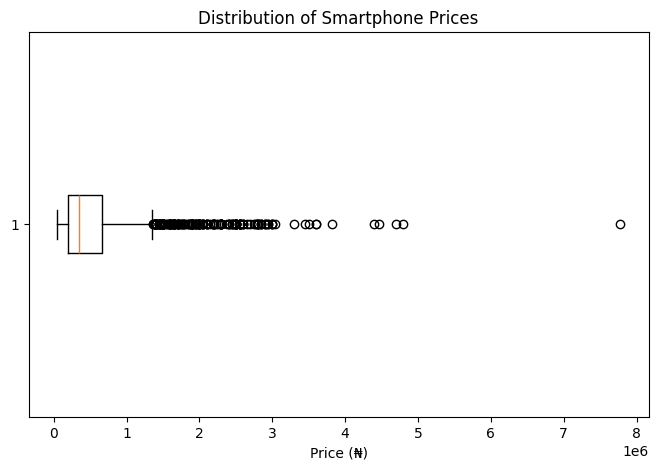

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(product_info["price"], vert=False)
plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (₦)")
plt.show()

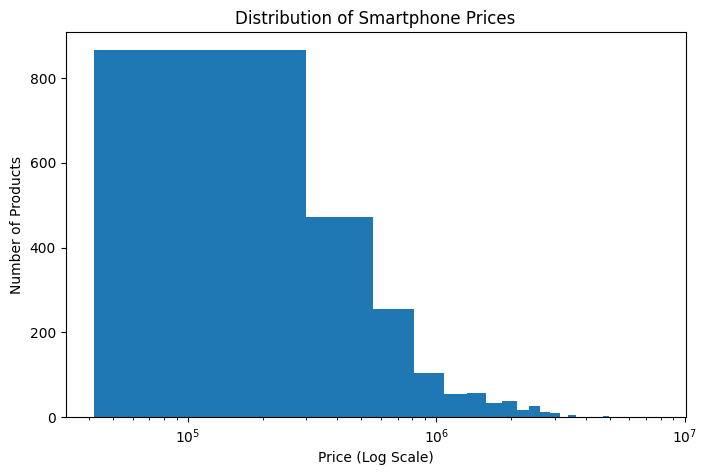

In [58]:
plt.figure(figsize=(8, 5))
plt.hist(product_info["price"], bins=30)
plt.xscale("log")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Number of Products")
plt.title("Distribution of Smartphone Prices")
plt.show()

In [59]:
product_info["discount"] = (
    product_info["discount"]
    .astype(str)
    .str.extract(r"(\d+)")
)

product_info["discount"] = pd.to_numeric(product_info["discount"], errors="coerce").fillna(0)

In [60]:
num_cols = ["rating", "reviews", "discount"]

for col in num_cols:
    product_info[col] = pd.to_numeric(product_info[col], errors="coerce")

In [61]:
product_info["reviews"] = product_info["reviews"].fillna(0)
#product_info["discount"] = product_info["discount"].fillna(0)
product_info["rating"] = product_info["rating"].fillna(product_info["rating"].median())

In [62]:
product_info.isna().sum()

name             0
price            0
image            0
link             0
discount         0
rating           0
reviews          0
brand            0
ram            225
storage         16
os             180
color          496
model          269
screen_size    292
dtype: int64

In [63]:
product_info.head()

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size
0,"Samsung Galaxy A07 6.7"" 4GB RAM/128GB ROM - Black",162869.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a07-6....,7,4.1,306,Samsung,4GB,128GB,Android,Black,Galaxy A07,6.7
1,XIAOMI REDMI A7 PRO - 6.9'' 4GB RAM/128GB ROM ...,166125.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-a7-pro-6...,8,4.1,118,Xiaomi,4GB,128GB,Android,RED,REDMI A7,6.9
2,"Samsung Galaxy A17 6.7"" HD 6GB RAM/128GB ROM A...",235614.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a17-6....,9,4.5,122,Samsung,6GB,128GB,Android 14,Black,Galaxy A17,6.7
3,"Poco C81 Pro 6.9"" 4GB RAM / 128GB ROM Android ...",136999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-c81-pro-6.9-4gb-...,24,4.9,9,Poco,4GB,128GB,Android 15,Black,Poco C81 Pro,6.9
4,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,169946.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13,4.1,750,Xiaomi,4GB,128GB,Android 15,Red,Redmi 15C,6.9


In [64]:
product_info["name"]

0       Samsung Galaxy A07 6.7" 4GB RAM/128GB ROM - Black
1       XIAOMI REDMI A7 PRO - 6.9'' 4GB RAM/128GB ROM ...
2       Samsung Galaxy A17 6.7" HD 6GB RAM/128GB ROM A...
3       Poco C81 Pro 6.9" 4GB RAM / 128GB ROM Android ...
4       XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...
                              ...                        
1947    Huawei Mate X7 8.0'' Foldable 16GB RAM 512GB R...
1948    Realme Note 50 - 6.74" (4GB RAM, 128GB ROM) An...
1949    itel A200+ 3gb (Expandable to 8gb Ram) 64gb Ro...
1950    Hmd LUMA 8GB RAM+128GB ROM 50MP Camera DUAL SI...
1951    Samsung Galaxy A17 5G 6.7" 8GB RAM 256GB ROM A...
Name: name, Length: 1952, dtype: str